### STEP 1: IMPORT DEPENDENCIES
Here’s the Keras code to import the needed dependencies:

In [1]:
!pip install tensorflow keras numpy matplotlib

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import regularizers, optimizers
import numpy as np
from matplotlib import pyplot

# Keras library to download the datasets, preprocess images, and network components
# Imports numpy for math operations
# Imports the matplotlib library to visualize results

### STEP 2: GET THE DATA READY FOR TRAINING
Keras has some datasets available for us to download and experiment with.

These datasets are usually preprocessed and almost ready to be fed to the neural network.

In this project, we use the CIFAR-10 dataset, which consists of 50,000 32 × 32 color train ing images, labeled over 10 categories, and 10,000 test images.

Check the Keras documentation for more datasets like CIFAR-100, MNIST, Fashion-MNIST, and more.

Keras provides the CIFAR-10 dataset already split into training and testing sets.

We will load them and then split the training dataset into 45,000 images for training and 5,000 images for validation, as explained in this chapter:

In [3]:
# Downloads and splits the data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Breaks the training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

print('x_train =', x_train.shape)
print('x_valid =', x_valid.shape)
print('x_test =', x_test.shape)
# The format of the shape tuple is as follows: (number of instances, width, height, channels).


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
x_train = (45000, 32, 32, 3)
x_valid = (5000, 32, 32, 3)
x_test = (10000, 32, 32, 3)


#### Normalize the data
Normalizing the pixel values of our images is done by subtracting the mean from each pixel and then dividing the result by the standard deviation:

In [4]:
mean = np.mean(x_train,axis=(0,1,2,3))
std = np.std(x_train,axis=(0,1,2,3))
x_train = (x_train-mean)/(std+1e-7)
x_valid = (x_valid-mean)/(std+1e-7)
x_test = (x_test-mean)/(std+1e-7)


#### One-hot encode the labels
To one-hot encode the labels in the train, valid, and test datasets, we use the to_categorical function in Keras:   

In [5]:
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)


#### Data augmentation
For augmentation techniques, we will arbitrarily go with the following transforma tions: rotation, width and height shift, and horizontal flip.

When you are working on problems, view the images that the network missed or provided poor detections for and try to understand why it is not performing well on them.

Then reate your hypothesis and experiment with it.

For example, if the missed images were of shapes that are rotated, you might want to try the rotation augmentation.

You would apply that, experiment, evaluate, and repeat.

You will come to your decisions purely from analyzing your data and understanding the network performance:

In [6]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
    )

# Computes the data augmentation on the training set
datagen.fit(x_train)

### STEP 3: BUILD THE MODEL ARCHITECTURE
In chapter 3, we built an architecture inspired by AlexNet (3 CONV + 2 FC). In this project, we will build a deeper network for increased learning capacity (6 CONV + 1 FC).

The network has the following configuration:

- Instead of adding a pooling layer after each convolutional layer, we will add oneafter every two convolutional layers. This idea was inspired by VGGNet, a popular neural network architecture developed by the Visual Geometry Group (University of Oxford). VGGNet will be explained in chapter 5.
- Inspired by VGGNet, we will set the kernel_size of our convolutional layers to 3 × 3 and the pool_size of the pooling layer to 2 × 2.
- We will add dropout layers every other convolutional layer, with (p) ranges from 0.2 and 0.4.
- A batch normalization layer will be added after each convolutional layer to normalize the input for the following layer.
- In Keras, L2 regularization is added to the convolutional layer code.

In [7]:
base_hidden_units = 32
weight_decay = 1e-4
model = Sequential()

# CONV1
model.add(Conv2D(base_hidden_units, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay),
input_shape=x_train.shape[1:]))
model.add(Activation('relu'))
model.add(BatchNormalization())

# CONV2
model.add(Conv2D(base_hidden_units, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# CONV3
model.add(Conv2D(base_hidden_units * 2, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# CONV4
model.add(Conv2D(base_hidden_units * 2, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# CONV5
model.add(Conv2D(base_hidden_units * 4, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# CONV6
model.add(Conv2D(base_hidden_units * 4, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

# FC7
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 309,290 (1.18 MB)

 Trainable params: 308,394 (1.18 MB)

 Non-trainable params: 896 (3.50 KB)

### STEP 4: TRAIN THE MODEL
Before we jump into the training code, let’s discuss the strategy behind some of the hyperparameter settings:

- batch_size: This is the mini-batch hyperparameter that we covered in this chapter. The higher the batch_size, the faster your algorithm learns. You can start with a mini-batch of 64 and double this value to speed up training. I tried 256 on my machine and got the following error, which means my machine was running out of memory. I then lowered it back to 128: Resource exhausted: OOM when allocating tensor with shape[256,128,4,4]
- epochs: I started with 50 training iterations and found that the network was still improving. So I kept adding more epochs and observing the training results. In this project, I was able to achieve >90% accuracy after 125 epochs. As you will see soon, there is still room for improvement if you let it train longer.
- Optimizer:I used the Adam optimizer. See section 4.7 to learn more about optimization algorithms

In [8]:
batch_size = 128
epochs = 125

checkpointer = tf.keras.callbacks.ModelCheckpoint(
    filepath='model.100epochs.keras',
    verbose=1,
    save_best_only=True,
    monitor='val_loss'
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    callbacks=[checkpointer],
    steps_per_epoch=x_train.shape[0] // batch_size,
    epochs=epochs,
    verbose=2,
    validation_data=(x_valid, y_valid)
)

Epoch 1/125

Epoch 1: val_loss improved from None to 2.06577, saving model to model.100epochs.keras

Epoch 1: finished saving model to model.100epochs.keras
351/351 - 48s - 138ms/step - accuracy: 0.2694 - loss: 2.8247 - val_accuracy: 0.2892 - val_loss: 2.0658
Epoch 2/125


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 2.06577 to 2.06445, saving model to model.100epochs.keras

Epoch 2: finished saving model to model.100epochs.keras
351/351 - 1s - 2ms/step - accuracy: 0.2812 - loss: 2.4527 - val_accuracy: 0.2884 - val_loss: 2.0644
Epoch 3/125

Epoch 3: val_loss improved from 2.06445 to 1.50796, saving model to model.100epochs.keras

Epoch 3: finished saving model to model.100epochs.keras
351/351 - 26s - 74ms/step - accuracy: 0.3603 - loss: 2.1061 - val_accuracy: 0.4834 - val_loss: 1.5080
Epoch 4/125

Epoch 4: val_loss did not improve from 1.50796
351/351 - 1s - 2ms/step - accuracy: 0.4062 - loss: 1.8956 - val_accuracy: 0.4834 - val_loss: 1.5088
Epoch 5/125

Epoch 5: val_loss improved from 1.50796 to 1.45977, saving model to model.100epochs.keras

Epoch 5: finished saving model to model.100epochs.keras
351/351 - 25s - 72ms/step - accuracy: 0.4062 - loss: 1.8606 - val_accuracy: 0.5038 - val_loss: 1.4598
Epoch 6/125

Epoch 6: val_loss did not improve from 1.45977
351/351 

### STEP 5: EVALUATE THE MODEL
To evaluate the model, we use a Keras function called evaluate and print the results:

In [9]:
scores = model.evaluate(x_test, y_test, batch_size=128, verbose=1)
print('\nTest result: %.3f loss: %.3f' % (scores[1]*100,scores[0]))

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7993 - loss: 0.6574

Test result: 79.930 loss: 0.657


#### Plot learning curves
Plot the learning curves to analyze the training performance and diagnose overfitting and underfitting

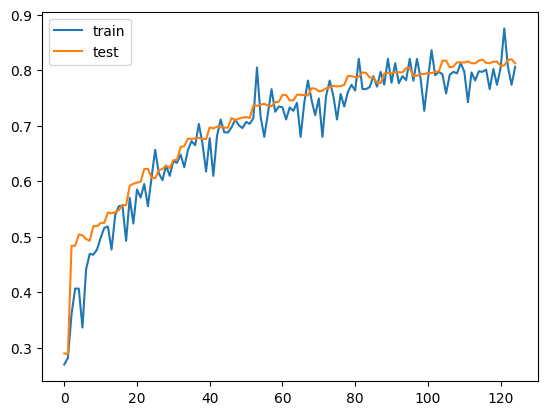

In [11]:
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()